# Task 2: Restaurant Recommendation System

## Objective
Develop a restaurant recommendation system that suggests the best restaurants based on restaurant ratings and other important features such as cuisine, price range, and online delivery.

## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\megha\OneDrive\Desktop\Cognifyz_ML_Internship
['.ipynb_checkpoints', 'anaconda_projects', 'Dataset', 'Task1_Rating_Prediction', 'Task2_Restaurant_Recommendation', 'Untitled.ipynb']


In [12]:
import os
print(os.listdir("Dataset"))

['Dataset.csv.csv']


## Step 2: Load and Explore the Dataset

In [13]:
df = pd.read_csv("Dataset/Dataset.csv.csv")

In [14]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [15]:
df.shape

(9551, 21)

In [16]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

## Step 3: Data Preprocessing

In [18]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [19]:
df["Cuisines"] = df["Cuisines"].fillna(df["Cuisines"].mode()[0])

In [20]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [21]:
df.dtypes

Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range               int64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                     int64
dtype: object

## Step 4: Understand Recommendation Criteria

In [22]:
df[[
    "Restaurant Name",
    "City",
    "Cuisines",
    "Aggregate rating",
    "Price range",
    "Has Online delivery"
]].head()

,Restaurant Name,City,Cuisines,Aggregate rating,Price range,Has Online delivery
0,Le Petit Souffle,Makati City,"French, Japanese, Desserts",4.8,3,No
1,Izakaya Kikufuji,Makati City,Japanese,4.5,3,No
2,Heat - Edsa Shangri-La,Mandaluyong City,"Seafood, Asian, Filipino, Indian",4.4,4,No
3,Ooma,Mandaluyong City,"Japanese, Sushi",4.9,4,No
4,Sambo Kojin,Mandaluyong City,"Japanese, Korean",4.8,4,No


In [23]:
df["Aggregate rating"].value_counts().sort_index()

Aggregate rating
0.0    2148
1.8       1
1.9       2
2.0       7
2.1      15
2.2      27
2.3      47
2.4      87
2.5     110
2.6     191
2.7     250
2.8     315
2.9     381
3.0     468
3.1     519
3.2     522
3.3     483
3.4     498
3.5     480
3.6     458
3.7     427
3.8     400
3.9     335
4.0     266
4.1     274
4.2     221
4.3     174
4.4     144
4.5      95
4.6      78
4.7      42
4.8      25
4.9      61
Name: count, dtype: int64

In [24]:
df["Aggregate rating"].max()

4.9

In [25]:
df["Aggregate rating"].min()

0.0

## Step 5: Recommend Top-Rated Restaurants

In [26]:
top_restaurants = df[df["Aggregate rating"] >= 4.5]

In [27]:
top_restaurants[[
    "Restaurant Name",
    "City",
    "Cuisines",
    "Aggregate rating",
    "Price range"
]].head(10)

,Restaurant Name,City,Cuisines,Aggregate rating,Price range
0,Le Petit Souffle,Makati City,"French, Japanese, Desserts",4.8,3
1,Izakaya Kikufuji,Makati City,Japanese,4.5,3
3,Ooma,Mandaluyong City,"Japanese, Sushi",4.9,4
4,Sambo Kojin,Mandaluyong City,"Japanese, Korean",4.8,4
8,Spiral - Sofitel Philippine Plaza Manila,Pasay City,"European, Asian, Indian",4.9,4
9,Locavore,Pasig City,Filipino,4.8,3
10,Silantro Fil-Mex,Pasig City,"Filipino, Mexican",4.9,3
12,Silantro Fil-Mex,Quezon City,"Filipino, Mexican",4.8,3
17,Balay Dako,Tagaytay City,Filipino,4.5,3
18,Hobing Korean Dessert Cafe,Taguig City,"Cafe, Korean, Desserts",4.5,2


In [28]:
len(top_restaurants)

301

In [52]:
top_restaurants = top_restaurants.sort_values(
    by="Aggregate rating",
    ascending=False
)
top_restaurants.head(10)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
9279,7422633,Talaga Sampireun,94,Jakarta,Jl. Lingkar Luar Barat,Cengkareng,"Cengkareng, Jakarta",106.728508,-6.168467,"Sunda, Indonesian",...,Indonesian Rupiah(IDR),No,No,No,No,3,4.9,Dark Green,Excellent,1662
9296,7417450,Talaga Sampireun,94,Tangerang,"Jl. Boulevard Bintaro Jaya Blok B7/N1, Bintaro...",Pondok Aren,"Pondok Aren, Tangerang",106.726119,-6.269914,"Sunda, Indonesian",...,Indonesian Rupiah(IDR),No,No,No,No,3,4.9,Dark Green,Excellent,2212
9299,7001086,Milse,148,Auckland,"The Pavilions, 27 Tyler Street, Britomart, Auc...",Britomart,"Britomart, Auckland",174.768690,-36.844188,Desserts,...,NewZealand($),No,No,No,No,3,4.9,Dark Green,Excellent,754
9303,18217279,Miann,148,Auckland,"57 Fort Street, Auckland Auckland CBD",Fort Street,"Fort Street, Auckland",174.768986,-36.846050,Desserts,...,NewZealand($),No,No,No,No,1,4.9,Dark Green,Excellent,281
213,17334212,Oakwood Cafe,216,Dalton,"201 West Cuyler Street, Dalton, GA 30720",Dalton,"Dalton, Dalton",-84.969393,34.769686,"BBQ, Breakfast, Southern",...,Dollar($),No,No,No,No,1,4.9,Dark Green,Excellent,249
235,17335156,Tantra Asian Bistro,216,Davenport,"589 East 53rd St, Davenport, IA 52807",Davenport,"Davenport, Davenport",-90.565837,41.574459,Asian,...,Dollar($),No,No,No,No,2,4.9,Dark Green,Excellent,474
374,17580142,McGuire's Irish Pub & Brewery,216,Pensacola,"600 E Gregory Street, Pensacola, FL 32502",Pensacola,"Pensacola, Pensacola",-87.202700,30.417900,"Burger, Bar Food, Steak",...,Dollar($),No,No,No,No,3,4.9,Dark Green,Excellent,2238
9262,2800856,Barbeque Nation,1,Vizag,"1st Floor, ATR Towers, Harbour Park Road, Pan...",Kirlampudi Layout,"Kirlampudi Layout, Vizag",0.000000,0.000000,"North Indian, Chinese, Mediterranean",...,Indian Rupees(Rs.),No,No,No,No,4,4.9,Dark Green,Excellent,345
3013,310143,Naturals Ice Cream,1,New Delhi,"L-8, Outer Circle, Connaught Place, New Delhi",Connaught Place,"Connaught Place, New Delhi",77.222148,28.634348,Ice Cream,...,Indian Rupees(Rs.),No,Yes,No,No,1,4.9,Dark Green,Excellent,2620
2536,3300958,Barbeque Nation,1,Nagpur,"2nd Floor, Eternity Mall, Amravati Road, Sitab...",Sitabuldi,"Sitabuldi, Nagpur",79.080247,21.143272,"North Indian, European, Mediterranean",...,Indian Rupees(Rs.),No,No,No,No,4,4.9,Dark Green,Excellent,226


## Step 6: Recommend Restaurants by Cuisine

In [30]:
df["Cuisines"].value_counts().head(10)

Cuisines
North Indian                      945
North Indian, Chinese             511
Fast Food                         354
Chinese                           354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64

In [31]:
north_indian = df[df["Cuisines"].str.contains("North Indian", case=False, na=False)]

In [53]:
north_indian = north_indian.sort_values(
    by="Aggregate rating",
    ascending=False
)
north_indian[[
    "Restaurant Name",
    "City",
    "Cuisines",
    "Aggregate rating",
    "Price range"
]].head(10)

,Restaurant Name,City,Cuisines,Aggregate rating,Price range
637,Sheroes Hangout,Agra,"Cafe, North Indian, Chinese",4.9,1
2495,Mirchi And Mime,Mumbai,"North Indian, South Indian, Mughlai",4.9,3
2289,Barbeque Nation,Guwahati,North Indian,4.9,4
2301,AB's - Absolute Barbecues,Hyderabad,"European, Mediterranean, North Indian",4.9,3
580,Punjab Grill,Abu Dhabi,"Indian, North Indian",4.9,4
9262,Barbeque Nation,Vizag,"North Indian, Chinese, Mediterranean",4.9,4
2536,Barbeque Nation,Nagpur,"North Indian, European, Mediterranean",4.9,4
822,AB's - Absolute Barbecues,Chennai,"North Indian, European, Mediterranean",4.9,3
850,The Great Indian Pub,Dehradun,North Indian,4.9,4
2414,Barbeque Nation,Kolkata,"North Indian, Chinese",4.9,3


In [33]:
len(north_indian)

3969

## Step 7: Recommend Restaurants by City

In [34]:
df["City"].value_counts().head(10)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64

In [35]:
new_delhi = df[df["City"] == "New Delhi"]

In [54]:
new_delhi = new_delhi.sort_values(
    by="Aggregate rating",
    ascending=False
)
new_delhi[[
    "Restaurant Name",
    "Cuisines",
    "Aggregate rating",
    "Price range",
    "Has Online delivery"
]].head(10)

,Restaurant Name,Cuisines,Aggregate rating,Price range,Has Online delivery
4298,Masala Library,Modern Indian,4.9,4,No
3601,Indian Accent - The Manor,Modern Indian,4.9,4,No
3013,Naturals Ice Cream,Ice Cream,4.9,1,Yes
6656,Kopper Kadai,North Indian,4.8,3,No
3012,MOB Brewpub,"Continental, Italian, Asian, Indian",4.7,3,No
7067,Pa Pa Ya,"Asian, Chinese, Thai, Japanese",4.7,4,No
3014,Zabardast Indian Kitchen,North Indian,4.7,3,Yes
6997,Echoes Satyaniketan,"Cafe, Continental, Italian, Mexican, Chinese, ...",4.7,2,No
6657,Naturals Ice Cream,Ice Cream,4.7,1,Yes
3310,Spezia Bistro,"Cafe, Continental, Chinese, Italian",4.6,2,Yes


In [37]:
len(new_delhi)

5473

## Step 8: Recommend Restaurants with Online Delivery

In [38]:
online_delivery = df[df["Has Online delivery"] == "Yes"]

In [39]:
online_delivery = online_delivery.sort_values(
    by="Aggregate rating",
    ascending=False
)

In [40]:
online_delivery[[
    "Restaurant Name",
    "City",
    "Cuisines",
    "Aggregate rating",
    "Price range"
]].head(10)

,Restaurant Name,City,Cuisines,Aggregate rating,Price range
841,CakeBee,Coimbatore,"Bakery, Desserts",4.9,2
2350,Zolocrust - Hotel Clarks Amer,Jaipur,"Italian, Bakery, Continental",4.9,4
1381,Caterspoint,Gurgaon,"Mexican, American, Healthy Food",4.9,2
3013,Naturals Ice Cream,New Delhi,Ice Cream,4.9,1
809,Chili's,Chennai,"Mexican, American, Tex-Mex, Burger",4.8,3
6657,Naturals Ice Cream,New Delhi,Ice Cream,4.7,1
3014,Zabardast Indian Kitchen,New Delhi,North Indian,4.7,3
2338,Tapri Central,Jaipur,"Cafe, Fast Food, Street Food",4.7,2
735,Truffles,Bangalore,"American, Burger, Cafe",4.7,2
2483,The Fusion Kitchen,Mumbai,"North Indian, Italian, Chinese, Mexican",4.7,3


In [41]:
len(online_delivery)

2451

## Step 9: Recommend Restaurants by Price Range

In [42]:
df["Price range"].value_counts().sort_index()

Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64

In [43]:
premium_restaurants = df[df["Price range"] == 4]

In [55]:
premium_restaurants = premium_restaurants.sort_values(
    by="Aggregate rating",
    ascending=False
)
premium_restaurants[[
    "Restaurant Name",
    "City",
    "Cuisines",
    "Aggregate rating",
    "Price range"
]].head(10)

,Restaurant Name,City,Cuisines,Aggregate rating,Price range
9514,Ministry of Crab,Colombo,Seafood,4.9,4
8,Spiral - Sofitel Philippine Plaza Manila,Pasay City,"European, Asian, Indian",4.9,4
48,Braseiro da G��vea,Rio de Janeiro,"Brazilian, Bar Food",4.9,4
50,Garota de Ipanema,Rio de Janeiro,"Brazilian, Bar Food",4.9,4
9484,Restaurant Mosaic @ The Orient,Pretoria,French,4.9,4
9424,Mainland China Restaurant,Doha,Chinese,4.9,4
850,The Great Indian Pub,Dehradun,North Indian,4.9,4
590,Carnival By Tresind,Dubai,Indian,4.9,4
9262,Barbeque Nation,Vizag,"North Indian, Chinese, Mediterranean",4.9,4
597,Tresind - Nassima Royal Hotel,Dubai,Indian,4.9,4


In [45]:
len(premium_restaurants)

586

## Step 10: Final Recommendation Table

In [46]:
final_recommendations = df[
    [
        "Restaurant Name",
        "City",
        "Cuisines",
        "Aggregate rating",
        "Price range",
        "Has Online delivery"
    ]
]

In [47]:
final_recommendations = final_recommendations.sort_values(
    by="Aggregate rating",
    ascending=False
)

In [48]:
final_recommendations.head(15)

,Restaurant Name,City,Cuisines,Aggregate rating,Price range,Has Online delivery
8,Spiral - Sofitel Philippine Plaza Manila,Pasay City,"European, Asian, Indian",4.9,4,No
10,Silantro Fil-Mex,Pasig City,"Filipino, Mexican",4.9,3,No
3,Ooma,Mandaluyong City,"Japanese, Sushi",4.9,4,No
9458,Urbanologi,Inner City,Tapas,4.9,4,No
507,Mazzaro's Italian Market,Tampa Bay,"Italian, Deli",4.9,1,No
509,Mr. Dunderbak's Biergarten and Marketplatz,Tampa Bay,"European, German",4.9,3,No
429,Marukame Udon,Rest of Hawaii,Japanese,4.9,1,No
428,Mama's Fish House,Rest of Hawaii,"Hawaiian, Seafood",4.9,4,No
580,Punjab Grill,Abu Dhabi,"Indian, North Indian",4.9,4,No
589,AB's Absolute Barbecues,Dubai,"Continental, Indian",4.9,3,No


## Step 11: Visualization

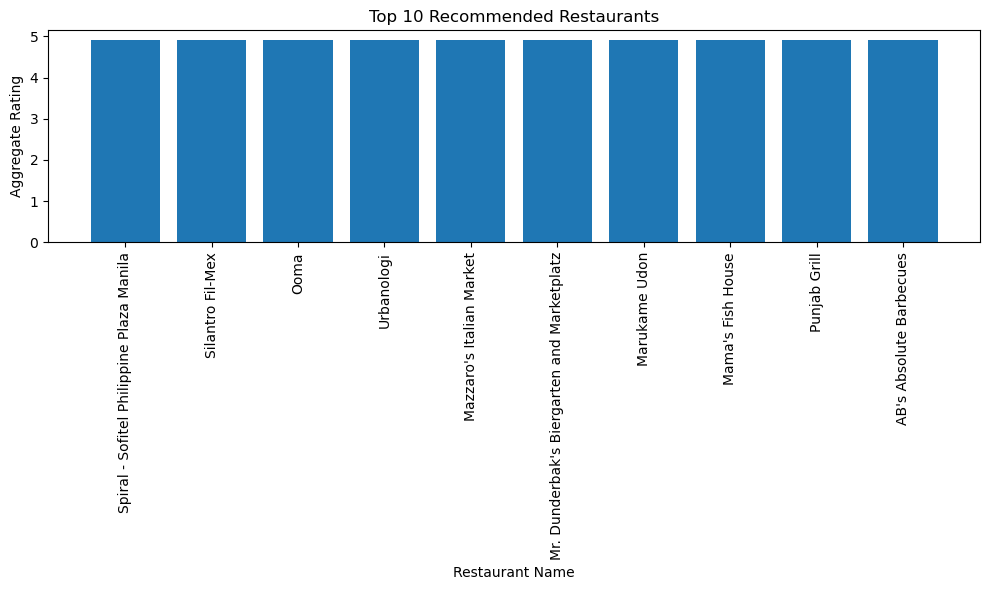

In [50]:
import matplotlib.pyplot as plt
top10 = final_recommendations.head(10)
plt.figure(figsize=(10, 6))
plt.bar(
    top10["Restaurant Name"],
    top10["Aggregate rating"]
)
plt.xticks(rotation=90)
plt.xlabel("Restaurant Name")
plt.ylabel("Aggregate Rating")
plt.title("Top 10 Recommended Restaurants")
plt.tight_layout()
plt.show()

## Step 12: Final Results

In [51]:
print("Restaurant Recommendation System Completed Successfully")
print(f"Total Restaurants: {len(df)}")
print(f"Highly Rated Restaurants (Rating ≥ 4.5): {len(top_restaurants)}")
print(f"North Indian Restaurants: {len(north_indian)}")
print(f"Restaurants in New Delhi: {len(new_delhi)}")
print(f"Restaurants with Online Delivery: {len(online_delivery)}")
print(f"Premium Restaurants (Price Range = 4): {len(premium_restaurants)}")

Restaurant Recommendation System Completed Successfully
Total Restaurants: 9551
Highly Rated Restaurants (Rating ≥ 4.5): 301
North Indian Restaurants: 3969
Restaurants in New Delhi: 5473
Restaurants with Online Delivery: 2451
Premium Restaurants (Price Range = 4): 586


# Task 2 Summary

**Status:** Completed ✅

The restaurant recommendation system was successfully developed using data filtering and sorting techniques. Restaurants were recommended based on aggregate rating, cuisine, city, online delivery availability, and price range.

**Results**
- Recommended top-rated restaurants.
- Generated cuisine-wise restaurant recommendations.
- Identified the best restaurants in a selected city.
- Filtered restaurants offering online delivery.
- Recommended premium restaurants based on price range.
- Created a final recommendation table and visualization.

**Conclusion:** The restaurant recommendation system successfully provides meaningful recommendations based on multiple user preferences and restaurant characteristics.